In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/content/preparations.py'>

In [ ]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf #Used to build and train deep learning models.
from tensorflow.keras.models import Model # lets you use the Functional API (very flexible)
from tensorflow.keras.layers import Input #input layer (image size)
from tensorflow.keras.layers import Dense #classic fully connected layers
from tensorflow.keras.layers import GlobalAveragePooling2D #flattens CNN features into 1D
from tensorflow.keras.layers import Dropout #prevents overfitting

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping #stops training early if there's no improvement.
from tensorflow.keras.callbacks import ReduceLROnPlateau #lowers the learning rate when validation stops improving.

# Reporting t
from sklearn.metrics import classification_report #gives precision, recall, F1-score
from sklearn.metrics import confusion_matrix #shows where the model makes mistakes
from imblearn.metrics import classification_report_imbalanced #better for imbalanced data



# Imports for visualizations
import matplotlib.pyplot as plt # for visualizing loss, accuracy, confusion matrix, etc.
import seaborn as sns
%matplotlib inline #required in notebooks to display plots directly below code.

### Try with Transfer Learning with EfficientNetB1

##### Dataset loading and preprocessing

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()
#Checks if the dataset is already downloaded.
#If not, it downloads and rearranges the files into folders:COVID, Lung_Opacity, Normal, Viral Pneumonia
#Each folder contains a subfolder masks/ for segmentation labels (even if unused here).

Dataset already exists.


In [ ]:
# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images(input_shape=(256,256))
#Loads the chest X-ray dataset.
#Resizes each image to 256x256 pixels.
#Splits the dataset:
#train_ds: 16,932 training images
#val_ds: 4,233 validation images
#Returns class_names: the list of disease categories:

Created empty directory: /tmp_945439036
Made directory: /tmp_945439036/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_945439036/Lung_Opacity/masks
Made directory: /tmp_945439036/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_945439036/COVID/masks
Made directory: /tmp_945439036/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_945439036/Viral Pneumonia/masks
Made directory: /tmp_945439036/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_945439036/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 256, 256, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 256, 256, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_945439036/Lun

In [ ]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy()) #530 Batches im Trainingsdatensatz (16.932 Bilder / 32 pro Batch)

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy()) #133 Batches im Validierungsdatensatz (4.233 Bilder / 32 pro Batch)

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 256, 256, 3) (32,)
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 3
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 3
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0


In [ ]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1 #This builds a dictionary like:

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label]) #These weights will be passed to the fit() function using class_weight=class_weights_dict.
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


#### Try with EfficientNetB1 (pretrained)

In [ ]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')): #setting up the infrastructure to save/load the model:
    os.makedirs(os.path.join('..', 'models'))

# This model name for saving and loading
model_name = os.path.join('..', 'models', '4_preproc_effnetb1retrained_dense128.keras')

In [ ]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.efficientnet import preprocess_input
#importing the ImageNet-style normalization that EfficientNetB1 expects

# Note: We moved this into the model, so no further need for preprocessing needed
# when testing the model on random files (e.g. from the internet), which makes the model easier to use
#train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
#val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
# Imports for using a pre-trained model
from tensorflow.keras.applications import EfficientNetB1

# EfficientNetB1 model
# Load the EfficientNetB1 model without its top classification layers
# and set the expected input shape for our dataset (256x256 RGB images)
base_model = EfficientNetB1(include_top=False, input_shape=(256, 256, 3))

# Let the whole model retrain, starting from its pretrained weights
# Allow all layers of the pretrained model to be trainable (fine-tuning)
base_model.trainable = True

# Model creation using the Functional API
inputs = Input(shape=(256, 256, 3)) # Define the model's input layer

# Preprocessing
x = preprocess_input(inputs) # Apply EfficientNetB1-style preprocessing to the input

# Build the model
x = base_model(x) # Pass the preprocessed image through the EfficientNetB1 base model
x = GlobalAveragePooling2D()(x) # Use global average pooling to reduce feature map size
x = Dense(1024, activation='relu')(x) # Fully connected dense layer with 1024 neurons and ReLU activation
x = Dropout(rate=0.2)(x) # Dropout for regularization (prevent overfitting)
x = Dense(128, activation='relu')(x) # Another dense layer with 128 neurons
x = Dropout(rate=0.2)(x) # Another Dropout layer
outputs = Dense(len(class_names), activation='softmax')(x) # Final output layer with as many neurons as classes, using softmax for probabilities

effnet = Model(inputs=inputs, outputs=outputs) # Combine input and output into the final model

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Applied Callbacks
early_stopping = EarlyStopping( ## Stop training early if validation loss doesn't improve (prevents overfitting)
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min', # We want to minimize validation loss
                                monitor='val_loss') # Watch validation loss

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss", # Watch validation loss
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01, # Only reduce if loss change is <1%
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1) # Print when reducing

In [ ]:
# Compile with first idea of appropriate parameters
# Compile the model with an optimizer, loss function and evaluation metric
effnet.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
 # Adaptive learning optimizer (commonly used)
 # Use this when labels are integers, not one-hot encoded
 # Track accuracy while training

# Print how it looks like
effnet.summary() # Display model architecture: layers, output shapes, parameter count

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(effnet)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb1 (Functional)          │ (None, 8, 8, 1280)          │       6,575,239 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,018,699 (30.59 MB)

 Trainable params: 7,956,644 (30.35 MB)

 Non-trainable params: 62,055 (242.41 KB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 256, 256, 3)",0
1,efficientnetb1 (Functional),"(None, 8, 8, 1280)","6,575,239"
2,global_average_pooling2d,"(None, 1280)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","1,311,744"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 128)","131,200"
7,dropout_1 (Dropout),"(None, 128)",0
8,dense_2 (Dense),"(None, 4)",516


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = effnet.fit(train_ds, # Training dataset
                          epochs=25, # Train for up to 25 epochs
                          validation_data=val_ds, # Validation dataset to monitor overfitting
                          class_weight=class_weights_dict, # To handle class imbalance
                          callbacks=[early_stopping, reduce_learning_rate]) # Early stopping + LR scheduler

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 246s 220ms/step - accuracy: 0.8068 - loss: 0.4685 - val_accuracy: 0.8897 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9175 - loss: 0.1939 - val_accuracy: 0.9308 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9326 - loss: 0.1474 - val_accuracy: 0.9372 - val_loss: 0.1988 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9335 - loss: 0.1392 - val_accuracy: 0.9239 - val_loss: 0.3575 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9400 - loss: 0.1462 - val_accuracy: 0.9440 - val_loss: 0.1905 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.9489 - loss: 0.1207 - val_accuracy: 0.9502 - val_loss: 0.1812 - learning_rate: 0.0010
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9481 -

In [20]:
# Save the model for potential later use
effnet.save(model_name)

##### Evalution

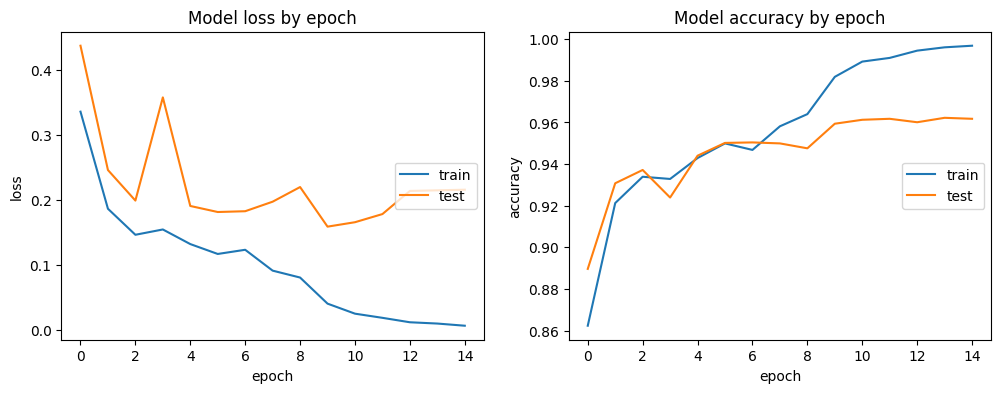

In [ ]:
hlp.plot_learning_curve(history_model)
#This visualizes how the model learned over epochs:

#Left Plot (Loss):
#-Training loss keeps going down – good!
#-Validation loss fluctuates slightly – normal behavior but worth monitoring for overfitting.

#Right Plot (Accuracy):
#-Accuracy improves and stabilizes around ~96% on validation.
#-Slight gap between training and validation → minimal overfitting.



> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

#Validation accuracy plateaus around ~96%, nomore 70%!

In [ ]:
from tensorflow import keras # Load the trained model from disk
effnet = keras.models.load_model(model_name)

In [ ]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(effnet, val_ds) # Get true labels and predictions

,pre,rec,spe,f1,geo,iba,sup
COVID,0.994366,0.990182,0.998864,0.992270,0.994514,0.988198,713.000000
Lung_Opacity,0.944541,0.935622,0.979140,0.940060,0.957134,0.912118,1165.000000
Normal,0.958454,0.964043,0.960460,0.961240,0.962250,0.926256,2058.000000
Viral Pneumonia,0.973244,0.979798,0.997967,0.976510,0.988841,0.976030,297.000000
avg_pre,0.961712,0.961712,0.961712,0.961712,0.961712,0.961712,0.961712
avg_rec,0.961729,0.961729,0.961729,0.961729,0.961729,0.961729,0.961729
avg_spe,0.974701,0.974701,0.974701,0.974701,0.974701,0.974701,0.974701
avg_f1,0.961709,0.961709,0.961709,0.961709,0.961709,0.961709,0.961709
avg_geo,0.968142,0.968142,0.968142,0.968142,0.968142,0.968142,0.968142
avg_iba,0.936291,0.936291,0.936291,0.936291,0.936291,0.936291,0.936291


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,706,0,6,1
Lung_Opacity,1,1090,74,0
Normal,3,64,1984,7
Viral Pneumonia,0,0,6,291


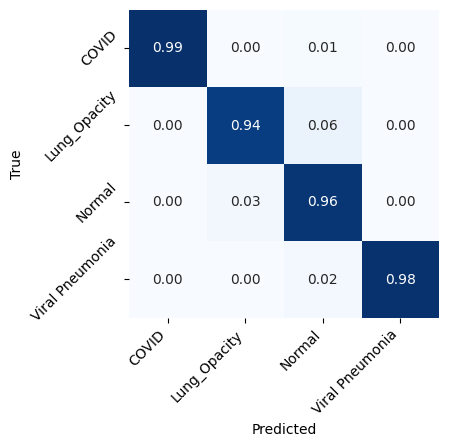

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              706             0       6                1
 Lung_Opacity         1          1090      74                0
 Normal               3            64    1984                7
 Viral Pneumonia      0             0       6              291,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.994366     0.990182     0.998864     0.992270   
 Lung_Opacity        0.944541     0.935622     0.979140     0.940060   
 Normal              0.958454     0.964043     0.960460     0.961240   
 Viral Pneumonia     0.973244     0.979798     0.997967     0.976510   
 avg_pre             0.961712     0.961712     0.961712     0.961712   
 avg_rec             0.961729     0.961729     0.961729     0.961729   
 avg_spe             0.974701     0.974701     0.974701     0.974701   
 avg_f1              0.961709     0.961709     0.961709     0.961709   

In [ ]:
hlp.report_model_performance(y_true, y_pred, class_names)
#This will print:
#-Precision, Recall, F1 per class
#-Overall metrics (macro/micro avg)
#-Confusion matrix

#Perfect for understanding how well the model distinguishes:
#-COVID vs. Pneumonia vs. Normal vs. Lung Opacity#

# Conclusion: This is great performance!